# Multiple Comparisons

## Overview

When many hypotheses are tested simultaneously, the probability of at least one false positive grows rapidly. With 20 independent tests at α=0.05, the expected number of false positives is 1, even if all null hypotheses are true.

**Error rate definitions:**

| Rate | Definition | Controls |
|---|---|---|
| FWER | P(any false positive) | Bonferroni, Holm |
| FDR | E(false positives / total positives) | Benjamini-Hochberg |
| Per-comparison | α per individual test | No correction |

**When to use which:**
- Bonferroni/Holm: small number of pre-specified hypotheses; confirmatory studies
- Benjamini-Hochberg (BH): large-scale testing (genomics, multi-site); discovery mode
- No correction: single pre-registered primary endpoint only

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings; warnings.filterwarnings('ignore')

rng = np.random.default_rng(42)

# Simulate multi-site experiment: 30 sites, test for restoration effect at each
# True: 8 sites have real effects; 22 are null
n_tests  = 30
n_true   = 8    # truly effective sites
n_null   = n_tests - n_true
n_obs    = 40   # observations per site

# Generate p-values
true_pvals = []
for _ in range(n_true):
    ctrl = rng.normal(15, 5, n_obs)
    trt  = rng.normal(18, 5, n_obs)   # real effect
    _, p = stats.ttest_ind(ctrl, trt)
    true_pvals.append(p)
null_pvals = []
for _ in range(n_null):
    ctrl = rng.normal(15, 5, n_obs)
    trt  = rng.normal(15, 5, n_obs)   # no effect
    _, p = stats.ttest_ind(ctrl, trt)
    null_pvals.append(p)
all_pvals = np.array(true_pvals + null_pvals)
is_true   = np.array([True]*n_true + [False]*n_null)
print(f"Generated {n_tests} p-values: {n_true} true effects, {n_null} nulls")

Generated 30 p-values: 8 true effects, 22 nulls


---
## Correction Methods

In [2]:
methods = {
    'Uncorrected':        (all_pvals < 0.05, None),
    'Bonferroni':         multipletests(all_pvals, alpha=0.05, method='bonferroni')[:2],
    'Holm':               multipletests(all_pvals, alpha=0.05, method='holm')[:2],
    'Benjamini-Hochberg': multipletests(all_pvals, alpha=0.05, method='fdr_bh')[:2],
}
print(f"{'Method':25s} {'Rejections':>12} {'True pos':>10} {'False pos':>10} {'FDR':>8}")
results = {}
for name, (rejected, _) in methods.items():
    tp = (rejected & is_true).sum()
    fp = (rejected & ~is_true).sum()
    fdr_obs = fp / max(rejected.sum(), 1)
    results[name] = {'rejected': rejected.sum(), 'tp': tp, 'fp': fp, 'fdr': fdr_obs}
    print(f"{name:25s} {rejected.sum():12d} {tp:10d} {fp:10d} {fdr_obs:8.3f}")
print("\nBonferroni: strict FWER control, fewer rejections")
print("B-H: controls FDR on average, more power in discovery settings")

Method                      Rejections   True pos  False pos      FDR
Uncorrected                          9          7          2    0.222
Bonferroni                           3          3          0    0.000
Holm                                 3          3          0    0.000
Benjamini-Hochberg                   4          4          0    0.000

Bonferroni: strict FWER control, fewer rejections
B-H: controls FDR on average, more power in discovery settings


---
## p-value Distribution Diagnostics

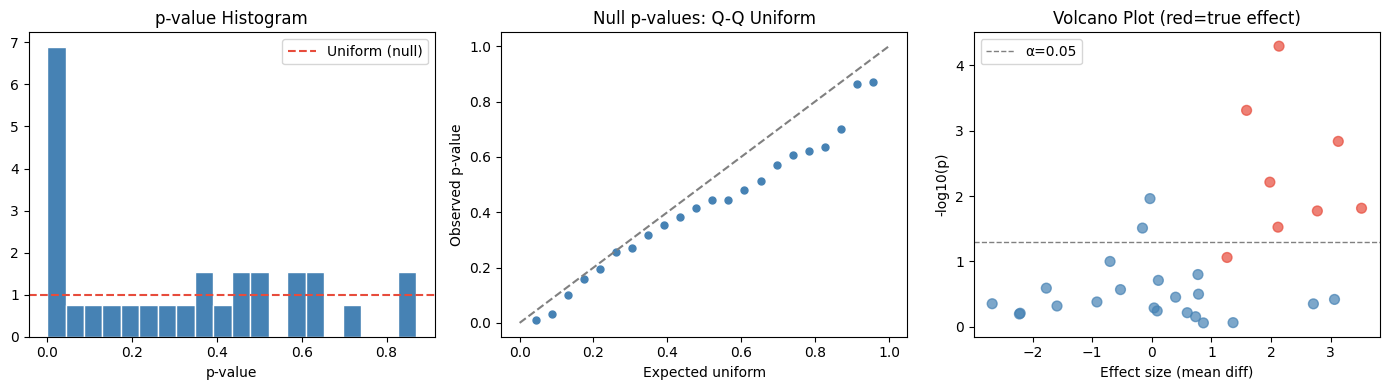

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# Histogram of all p-values
axes[0].hist(all_pvals, bins=20, color='steelblue', edgecolor='white', density=True)
axes[0].axhline(1.0, color='#e74c3c', lw=1.5, linestyle='--', label='Uniform (null)')
axes[0].set_xlabel('p-value'); axes[0].set_title('p-value Histogram')
axes[0].legend()

# Q-Q uniform plot for null p-values
null_pv_sorted = np.sort(null_pvals)
expected = (np.arange(1, n_null+1)) / (n_null+1)
axes[1].plot(expected, null_pv_sorted, 'o', ms=5, color='steelblue')
axes[1].plot([0,1],[0,1],'--', color='grey')
axes[1].set_xlabel('Expected uniform'); axes[1].set_ylabel('Observed p-value')
axes[1].set_title('Null p-values: Q-Q Uniform')

# Volcano plot
effect_sizes = []
for i in range(n_tests):
    is_t = i < n_true
    ctrl = rng.normal(15, 5, n_obs)
    trt  = rng.normal(18 if is_t else 15, 5, n_obs)
    _, p = stats.ttest_ind(ctrl, trt)
    effect_sizes.append(trt.mean() - ctrl.mean())
colors_v = ['#e74c3c' if t else 'steelblue' for t in is_true]
axes[2].scatter(effect_sizes, -np.log10(all_pvals), c=colors_v, alpha=0.7, s=50)
axes[2].axhline(-np.log10(0.05), color='grey', lw=1, linestyle='--', label='α=0.05')
axes[2].set_xlabel('Effect size (mean diff)'); axes[2].set_ylabel('-log10(p)')
axes[2].set_title('Volcano Plot (red=true effect)')
axes[2].legend()
plt.tight_layout(); plt.show()

---
## Adjusted p-values and q-values

In [4]:
# Adjusted p-values: smallest α at which each test would be rejected
rejected_bf, pvals_bf, _, _ = multipletests(all_pvals, alpha=0.05, method='bonferroni')
rejected_bh, pvals_bh, _, _ = multipletests(all_pvals, alpha=0.05, method='fdr_bh')

df_adj = pd.DataFrame({
    'raw_p':      all_pvals.round(4),
    'bonferroni': pvals_bf.round(4),
    'bh_adj':     pvals_bh.round(4),
    'true_effect': is_true,
    'reject_bh':  rejected_bh,
})
df_adj = df_adj.sort_values('raw_p').reset_index(drop=True)
print("Top 12 most significant tests after correction:")
print(df_adj.head(12).to_string(index=False))

# How many true effects recovered at FDR=0.10?
_, pvals_bh10, _, _ = multipletests(all_pvals, alpha=0.10, method='fdr_bh')
rej_10 = pvals_bh10 < 0.10
tp_10  = (rej_10 & is_true).sum()
fp_10  = (rej_10 & ~is_true).sum()
print(f"\nBH at FDR=0.10: {rej_10.sum()} rejections, {tp_10} true, {fp_10} false")

Top 12 most significant tests after correction:
 raw_p  bonferroni  bh_adj  true_effect  reject_bh
0.0001      0.0015  0.0015         True       True
0.0005      0.0147  0.0074         True       True
0.0015      0.0438  0.0146         True       True
0.0061      0.1842  0.0461         True       True
0.0110      0.3287  0.0657        False      False
0.0154      0.4614  0.0725         True      False
0.0169      0.5075  0.0725         True      False
0.0299      0.8985  0.1030         True      False
0.0309      0.9274  0.1030        False      False
0.0870      1.0000  0.2610         True      False
0.1001      1.0000  0.2730        False      False
0.1587      1.0000  0.3967        False      False

BH at FDR=0.10: 7 rejections, 6 true, 1 false


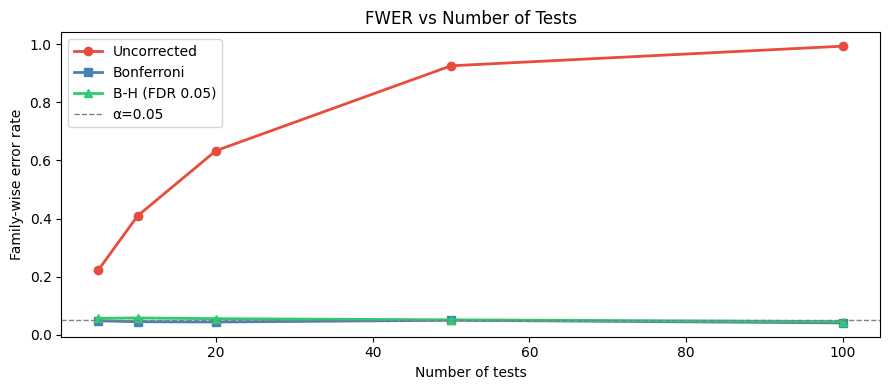

In [5]:
# Family-wise error rate simulation
def simulate_fwer(n_tests, alpha, correction, n_sim=2000):
    any_fp = 0
    for _ in range(n_sim):
        pvals = rng.uniform(0, 1, n_tests)   # all nulls
        if correction == 'none':
            rejected = pvals < alpha
        elif correction == 'bonferroni':
            rejected = pvals < alpha / n_tests
        elif correction == 'bh':
            rejected, _, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
        if rejected.any():
            any_fp += 1
    return any_fp / n_sim

test_counts = [5, 10, 20, 50, 100]
fwer_none = [simulate_fwer(k, 0.05, 'none') for k in test_counts]
fwer_bonf = [simulate_fwer(k, 0.05, 'bonferroni') for k in test_counts]
fwer_bh   = [simulate_fwer(k, 0.05, 'bh') for k in test_counts]
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(test_counts, fwer_none, 'o-', color='#e74c3c', lw=2, label='Uncorrected')
ax.plot(test_counts, fwer_bonf, 's-', color='steelblue', lw=2, label='Bonferroni')
ax.plot(test_counts, fwer_bh,   '^-', color='#2ecc71', lw=2, label='B-H (FDR 0.05)')
ax.axhline(0.05, color='grey', lw=1, linestyle='--', label='α=0.05')
ax.set_xlabel('Number of tests'); ax.set_ylabel('Family-wise error rate')
ax.set_title('FWER vs Number of Tests'); ax.legend()
plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Applying Bonferroni correction across the entire study including exploratory analyses**  
Bonferroni divides α by the number of tests, but if you include every exploratory comparison in that count, the correction becomes extremely conservative and power vanishes. Distinguish between pre-specified confirmatory hypotheses (require correction) and post-hoc exploratory comparisons (report uncorrected p-values with appropriate caveats).

**2. Using Benjamini-Hochberg when the goal is to confirm individual findings**  
BH controls the expected false discovery rate across the set of rejections — it guarantees that approximately 5% of declared discoveries are false, but individual discoveries may still be false positives. For confirmatory findings where each individual claim must be reliable, use FWER-controlling corrections (Holm or Bonferroni).

**3. Not specifying the family of hypotheses before data collection**  
The appropriate correction depends on how many tests were planned. If additional exploratory tests are added after seeing the data, the effective family size is unknown and any correction is post-hoc. Pre-register the complete set of planned tests before data collection.

**4. Applying correction to p-values from different, unrelated studies**  
Multiplicity corrections apply to tests from the same study or experiment where simultaneous false positives accumulate. Correcting across papers, years, or completely unrelated outcomes is not statistically meaningful and does not control any useful error rate.

**5. Treating "adjusted p > 0.05" as "the effect doesn't exist"**  
A non-significant result after multiplicity correction means the evidence is insufficient to reject H₀ while controlling the error rate at the specified level — it does not imply the effect is zero or unimportant. Report confidence intervals for all tested hypotheses regardless of significance.

---
*python_methods_library - Samantha McGarrigle*